# Estudo dos Hiperparâmetros
Explora o espaço de hiperparâmetros com curvas de aprendizado para definir ranges pro Optuna.

In [2]:
#Bibliotecas Utilizadas
import os
from pathlib import Path
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import itertools
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


In [3]:
load_dotenv()
DATA_PATH = os.getenv("DADOS_PROJETO")
dados = torch.load(DATA_PATH)

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [5]:
X_train_num      = dados['X_train_num'].float()
X_train_emb_base = dados['X_train_emb_base'].long()
X_train_emb_add  = dados['X_train_emb_add'].long()
y_train          = dados['y_train'].float()

X_test_num       = dados['X_test_num'].float()
X_test_emb_base  = dados['X_test_emb_base'].long()
X_test_emb_add   = dados['X_test_emb_add'].long()
y_test           = dados['y_test'].float()

NUM_FEATURES_CONTINUAS = X_train_num.shape[1]
VOCAB_BASE_SIZE        = int(X_train_emb_base.max().item() + 1)
VOCAB_ADD_SIZE         = int(X_train_emb_add.max().item() + 1)

print(f'Features contínuas : {NUM_FEATURES_CONTINUAS}')
print(f'Vocab base         : {VOCAB_BASE_SIZE}')
print(f'Vocab consumível   : {VOCAB_ADD_SIZE}')
print(f'Treino             : {X_train_num.shape[0]} amostras')
print(f'Teste              : {X_test_num.shape[0]} amostras')

Features contínuas : 74
Vocab base         : 72
Vocab consumível   : 73
Treino             : 609 amostras
Teste              : 153 amostras


In [6]:
class RedeSoldagem(nn.Module):
    def __init__(self, num_features_continuas, vocab_base_size, vocab_add_size,
                 emb_dim=4, hidden_size=64, num_layers=2, dropout_rate=0.2,activation=nn.ReLU()):
        super().__init__()
        self.emb_base = nn.Embedding(vocab_base_size, emb_dim)
        self.emb_add  = nn.Embedding(vocab_add_size,  emb_dim)
        entrada = num_features_continuas + emb_dim * 2
        camadas, atual = [], entrada
        for _ in range(num_layers):
            camadas += [nn.Linear(atual, hidden_size), activation,
                        nn.BatchNorm1d(hidden_size), nn.Dropout(dropout_rate)]
            atual = hidden_size
        self.ocultas = nn.Sequential(*camadas)
        self.saida   = nn.Linear(hidden_size, 3)

    def forward(self, x_num, x_base, x_add):
        x = torch.cat([x_num, self.emb_base(x_base), self.emb_add(x_add)], dim=1)
        return self.saida(self.ocultas(x))

## Função de treino com registro de curvas


In [14]:
def treinar_com_historico(params, epochs=100, batch_size=32):
    model = RedeSoldagem(
        num_features_continuas=NUM_FEATURES_CONTINUAS,
        vocab_base_size=VOCAB_BASE_SIZE,
        vocab_add_size=VOCAB_ADD_SIZE,
        emb_dim=params['emb_dim'],
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout_rate=params['dropout_rate'],
        activation=params.get('activation', nn.ReLU()),
    )

    dataset = TensorDataset(X_train_num, X_train_emb_base, X_train_emb_add, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    optimizer = optim.AdamW(model.parameters(), lr=params['learning_rate'])
    criterion = nn.MSELoss()
    historico_train = []
    historico_val = []

    for epoca in range(epochs):
        model.train()
        losses_batch = []
        for x_num, x_base, x_add, y_batch in loader:
            pred = model(x_num, x_base, x_add)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses_batch.append(loss.item())
        historico_train.append(np.mean(losses_batch))

        model.eval()
        with torch.no_grad():
            pred_val = model(X_test_num, X_test_emb_base, X_test_emb_add)
            val_loss = criterion(pred_val, y_test)
        historico_val.append(val_loss)

    return val_loss, historico_train, historico_val

### Grid de exploração
Estratégia: explorar amplamente primeiro para entender quais regiões do espaço são promissoras

In [41]:
param_grid = {
    'learning_rate': [1e-4, 1e-3,], 
    'hidden_size':   [128,256,512],
    'num_layers':    [2, 3],
    'dropout_rate':  [0.0, 0.05],
    'emb_dim':       [8, 16],
}

all_combos = list(itertools.product(*param_grid.values()))
keys = list(param_grid.keys())
print(f'Total de combinações possíveis: {len(all_combos)}')

SEED = 32
random.seed(SEED)
sample = random.sample(all_combos, k=48)
print(f'Amostras selecionadas para rodar: {len(sample)}')

Total de combinações possíveis: 48
Amostras selecionadas para rodar: 48


In [42]:
EPOCHS     = 100  
BATCH_SIZE = 32

resultados = []

for i, combo in enumerate(sample):
    params = dict(zip(keys, combo))
    label  = f"hs={params['hidden_size']} nl={params['num_layers']} lr={params['learning_rate']:.0e} dr={params['dropout_rate']} emb={params['emb_dim']}"

    #
    val_loss, hist_train, hist_val = treinar_com_historico(params, epochs=EPOCHS, batch_size=BATCH_SIZE)


    resultado_atual = {
        **params,
        'val_loss':   val_loss,
        'label':      label,
        'hist_train': hist_train,
        'hist_val':   hist_val,
    }
    
    resultados.append(resultado_atual)
    

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        

    if (i + 1) % 5 == 0:
        val_losses = [r["val_loss"] for r in resultados]
        print(f'[{i+1}/{len(sample)}] melhor até agora: {min(val_losses):.4f}')

df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('hist_train', 'hist_val')} for r in resultados])
df = df.sort_values('val_loss').reset_index(drop=True)

print('\nTop 10:')
print(df.head(10).to_string(index=False))


[5/48] melhor até agora: 0.1756
[10/48] melhor até agora: 0.1699
[15/48] melhor até agora: 0.1606
[20/48] melhor até agora: 0.1606
[25/48] melhor até agora: 0.1606
[30/48] melhor até agora: 0.1593
[35/48] melhor até agora: 0.1593
[40/48] melhor até agora: 0.1593
[45/48] melhor até agora: 0.1422

Top 10:
 learning_rate  hidden_size  num_layers  dropout_rate  emb_dim       val_loss                               label
        0.0010          128           2          0.05       16 tensor(0.1422) hs=128 nl=2 lr=1e-03 dr=0.05 emb=16
        0.0010          256           3          0.05       16 tensor(0.1593) hs=256 nl=3 lr=1e-03 dr=0.05 emb=16
        0.0010          512           3          0.00        8 tensor(0.1604)   hs=512 nl=3 lr=1e-03 dr=0.0 emb=8
        0.0001          512           3          0.00       16 tensor(0.1606)  hs=512 nl=3 lr=1e-04 dr=0.0 emb=16
        0.0010          256           2          0.05       16 tensor(0.1641) hs=256 nl=2 lr=1e-03 dr=0.05 emb=16
        0.0


### Visualização 1 — Curvas de aprendizado 
Mostra onde cada combinação para de aprender e se há overfitting.

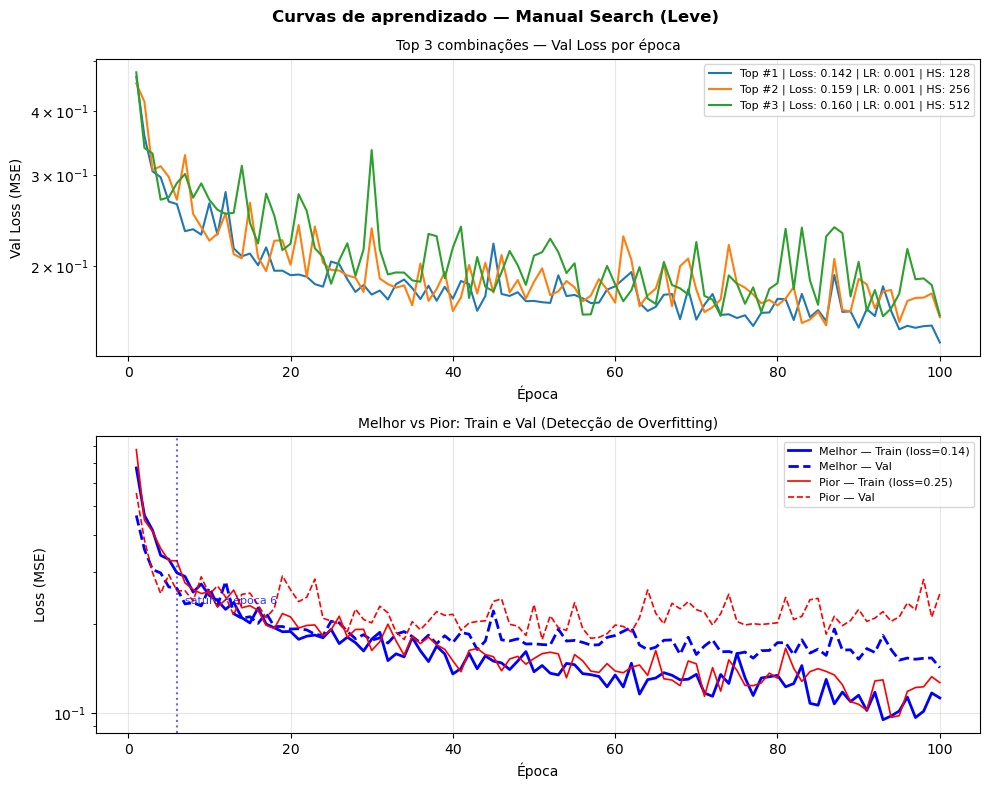

In [44]:
import numpy as np
import matplotlib.pyplot as plt

if 'resultados' in locals() and len(resultados) > 0:
    resultados_sorted = sorted(resultados, key=lambda r: r['val_loss'])
    top3 = resultados_sorted[:3] 
    

    EPOCHS = len(resultados_sorted[0]['hist_val'])
    epocas = range(1, EPOCHS + 1)

    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    fig.suptitle('Curvas de aprendizado — Manual Search (Leve)', fontsize=12, fontweight='bold', y=0.98)

    # ── Painel superior: Top 3 ──
    ax = axes[0]
    cores_top = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
    for i, r in enumerate(top3):
        label_simples = f"Top #{i+1} | Loss: {r['val_loss']:.3f} | LR: {r['learning_rate']} | HS: {r['hidden_size']}"
        ax.plot(epocas, r['hist_val'], color=cores_top[i], linewidth=1.5, label=label_simples)
    
    ax.set_title('Top 3 combinações — Val Loss por época', fontsize=10)
    ax.set_xlabel('Época')
    ax.set_ylabel('Val Loss (MSE)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    # ── Painel inferior: Melhores vs piores (val E train) ──
    ax2 = axes[1]
    melhor = resultados_sorted[0]
    pior  = resultados_sorted[-1]

    ax2.plot(epocas, melhor['hist_train'], 'b-',  linewidth=2.0, label=f'Melhor — Train (loss={melhor["val_loss"]:.2f})')
    ax2.plot(epocas, melhor['hist_val'],   'b--', linewidth=2.0, label='Melhor — Val')
    ax2.plot(epocas, pior['hist_train'],   'r-',  linewidth=1.2, label=f'Pior — Train (loss={pior["val_loss"]:.2f})')
    ax2.plot(epocas, pior['hist_val'],     'r--', linewidth=1.2, label='Pior — Val')


    hist_val_melhor = np.array(melhor['hist_val'])
    mask = np.isfinite(hist_val_melhor)
    
    if np.any(mask):
        diffs = np.abs(np.diff(hist_val_melhor[mask]))
        if len(diffs) > 0:
            saturacao = np.argmax(diffs < diffs.max() * 0.02)  
            if saturacao > 5:
                ax2.axvline(x=saturacao, color='blue', linestyle=':', alpha=0.6)
                ax2.text(saturacao + 1, hist_val_melhor[saturacao], f'satura ~época {saturacao}',
                         fontsize=8, color='blue', alpha=0.8)

    ax2.set_title('Melhor vs Pior: Train e Val (Detecção de Overfitting)', fontsize=10)
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss (MSE)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.show()
else:
    print("A variável 'resultados' não foi inicializada ou está vazia.")

## Visualização 2 — Impacto de cada hiperparâmetro
Boxplot mostrando a distribuição de `val_loss` para cada valor de cada parâmetro.
Parâmetros com boxes bem separados = alta influência.

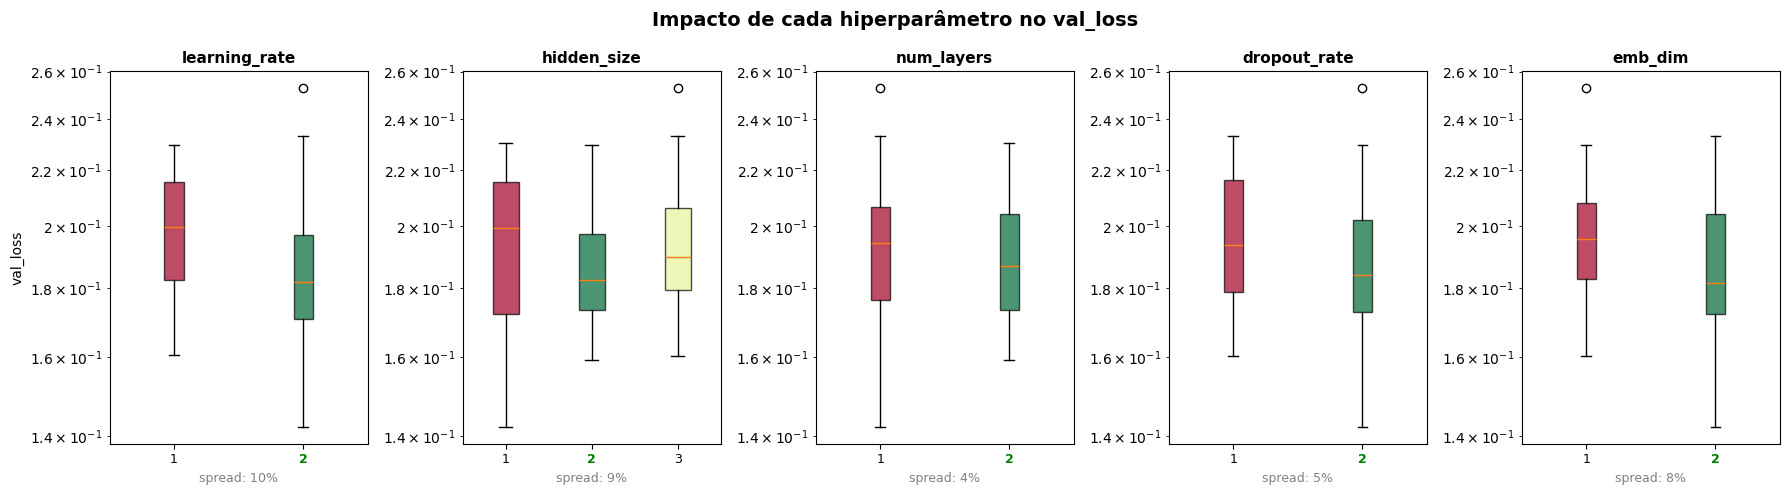


► Parâmetros com maior spread = mais importantes para o Optuna


In [45]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Impacto de cada hiperparâmetro no val_loss', fontsize=14, fontweight='bold')

for ax, col in zip(axes, keys):
    grupos  = df.groupby(col)['val_loss'].apply(list)
    valores = [grupos[k] for k in sorted(grupos.index)]
    labels  = [str(k) for k in sorted(grupos.index)]

    bp = ax.boxplot(valores, label=label, patch_artist=True, notch=False)

    # Colorir caixas do melhor para o pior pela mediana
    medianas = [np.median(v) for v in valores]
    norma    = plt.Normalize(min(medianas), max(medianas))
    for patch, med in zip(bp['boxes'], medianas):
        patch.set_facecolor(plt.cm.RdYlGn_r(norma(med)))
        patch.set_alpha(0.7)

    # Marcar o melhor valor de cada parâmetro
    melhor_idx = np.argmin(medianas)
    ax.get_xticklabels()[melhor_idx].set_color('green')
    ax.get_xticklabels()[melhor_idx].set_fontweight('bold')

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('val_loss' if ax == axes[0] else '')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)


    spread = (max(medianas) - min(medianas)) / min(medianas) * 100
    ax.set_xlabel(f'spread: {spread:.0f}%', fontsize=9, color='gray')

plt.tight_layout()

plt.show()

print('\n► Parâmetros com maior spread = mais importantes para o Optuna')

## Visualização 3 — Curvas de saturação agrupadas por parâmetro
Para cada parâmetro, plota as curvas médias de aprendizado separadas por valor.
Mostra se um valor de parâmetro aprende mais rápido, satura antes, ou converge melhor.

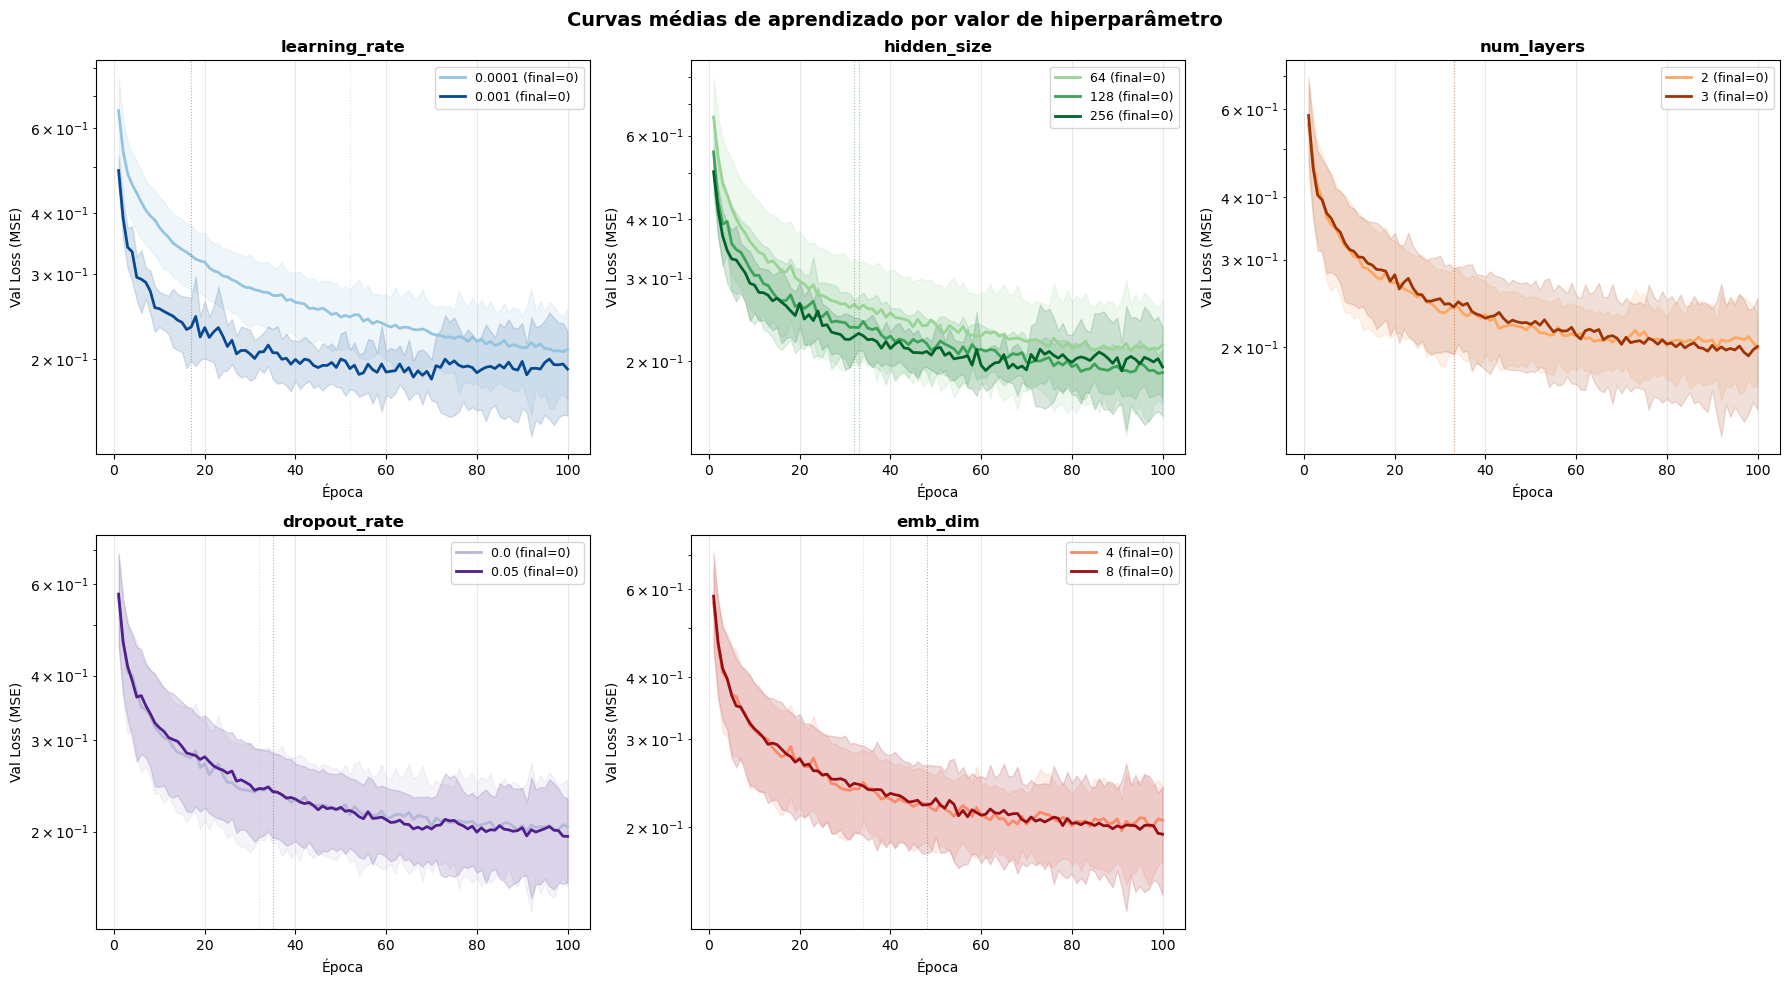

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Curvas médias de aprendizado por valor de hiperparâmetro', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

# Paleta consistente por valor de parâmetro
PALETAS = [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples, plt.cm.Reds]

for idx, (col, paleta) in enumerate(zip(keys, PALETAS)):
    ax     = axes_flat[idx]
    grupos = {}
    for r in resultados:
        v = r[col]
        if v not in grupos:
            grupos[v] = []
        grupos[v].append(r['hist_val'])

    valores_sorted = sorted(grupos.keys())
    cores = paleta(np.linspace(0.4, 0.9, len(valores_sorted)))

    for val, cor in zip(valores_sorted, cores):
        curvas     = np.array(grupos[val])           
        media      = curvas.mean(axis=0)
        desvio     = curvas.std(axis=0)
        loss_final = media[-1]

        ax.plot(range(1, EPOCHS + 1), media, color=cor, linewidth=2,
                label=f'{val} (final={loss_final:.0f})')
        ax.fill_between(range(1, EPOCHS + 1),
                         media - desvio, media + desvio,
                         color=cor, alpha=0.15)

        # Marcar época de saturação (quando a curva não melhora mais que 1%)
        for ep in range(10, EPOCHS - 1):
            if abs(media[ep] - media[ep - 5]) / (media[ep - 5] + 1e-8) < 0.01:
                ax.axvline(x=ep, color=cor, linestyle=':', alpha=0.4, linewidth=0.8)
                break

    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Val Loss (MSE)')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Esconder o último subplot vazio
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()


## Resumo e ranges recomendados para o Optuna
Com base nos gráficos acima, identifica automaticamente os melhores ranges.

In [23]:
# Pegar o top 20% dos resultados e ver os ranges que apareceram
n_top = max(3, len(df) // 5)  
df_top = df.head(n_top)


print(f'\nVal loss:  min={df_top.val_loss.min():.1f}  max={df_top.val_loss.max():.1f}')

print('\nRanges que apareceram nos melhores resultados:')
for col in keys:
    vals = df_top[col].unique()
    print(f'  {col:15s}: {sorted(vals)}')


print('RANGES SUGERIDOS PARA O OPTUNA :')

for col in keys:
    vals = sorted(df_top[col].unique())
    if len(vals) >= 2:
        lo, hi = vals[0], vals[-1]
        # Expandir levemente os limites para o Optuna explorar além dos pontos testados
        if col == 'learning_rate':
            print(f'  trial.suggest_float("{col}", {lo*0.5:.1e}, {hi*2:.1e}, log=True)')
        elif col in ('hidden_size', 'num_layers', 'emb_dim'):
            print(f'  trial.suggest_int("{col}", {int(lo)}, {int(hi)})')
        else:
            print(f'  trial.suggest_float("{col}", {lo:.2f}, {hi:.2f})')
    else:
        print(f'  # {col} = {vals[0]} (fixar — pouca variação no top)')


Val loss:  min=0.1  max=0.2

Ranges que apareceram nos melhores resultados:
  learning_rate  : [np.float64(0.001), np.float64(0.005)]
  hidden_size    : [np.int64(64), np.int64(128)]
  num_layers     : [np.int64(2), np.int64(3)]
  dropout_rate   : [np.float64(0.05), np.float64(0.1)]
  emb_dim        : [np.int64(4), np.int64(8), np.int64(12)]
RANGES SUGERIDOS PARA O OPTUNA :
  trial.suggest_float("learning_rate", 5.0e-04, 1.0e-02, log=True)
  trial.suggest_int("hidden_size", 64, 128)
  trial.suggest_int("num_layers", 2, 3)
  trial.suggest_float("dropout_rate", 0.05, 0.10)
  trial.suggest_int("emb_dim", 4, 12)


In [ ]:
import optuna
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float("learning_rate", 5.0e-04, 1.0e-02, log=True),
        'hidden_size':   trial.suggest_int("hidden_size", 32, 128),
        'num_layers':    trial.suggest_int("num_layers", 2, 3),
        'dropout_rate':  trial.suggest_float("dropout_rate", 0.00, 0.1),
        'emb_dim':       trial.suggest_int("emb_dim", 1,4)
    }
    
    model = RedeSoldagem(
        num_features_continuas=NUM_FEATURES_CONTINUAS,
        vocab_base_size=VOCAB_BASE_SIZE,
        vocab_add_size=VOCAB_ADD_SIZE,
        emb_dim=params['emb_dim'],
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout_rate=params['dropout_rate']
    )

    dataset   = TensorDataset(X_train_num, X_train_emb_base, X_train_emb_add, y_train)
    loader    = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])

    # Considerando a saturação média em torno de ~40 épocas, podemos usar um limite seguro aqui:
    epochs = 40
    
    for epoca in range(epochs):
        model.train()
        for x_num, x_base, x_add, y_batch in loader:
            pred = model(x_num, x_base, x_add)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_val = model(X_test_num, X_test_emb_base, X_test_emb_add)
        val_loss = criterion(pred_val, y_test).item()

    return val_loss

# 4. Executando a Otimização
if __name__ == "__main__":

    study = optuna.create_study(direction="minimize")
    
    print("Iniciando otimização com Optuna (Fase 2)... Aguarde.")
    # k=20 ou 30 trials costuma ser suficiente para refinar bem a busca
    study.optimize(objective, n_trials=25)
    print("\n" + "=" * 50)
    print("Otimização Concluída!")
    print(f"Melhor Val Loss (MSE): {study.best_value:.2f}")
    print("\nMelhores Hiperparâmetros Encontrados:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

[I 2026-06-23 16:21:00,374] A new study created in memory with name: no-name-6ac1caa4-c10f-451f-aab7-8fd222528e4f


Iniciando otimização com Optuna (Fase 2)... Aguarde.


[I 2026-06-23 16:21:01,296] Trial 0 finished with value: 0.2493688315153122 and parameters: {'learning_rate': 0.00714673216053126, 'hidden_size': 39, 'num_layers': 3, 'dropout_rate': 0.0675089207000512, 'emb_dim': 4}. Best is trial 0 with value: 0.2493688315153122.
[I 2026-06-23 16:21:02,218] Trial 1 finished with value: 0.20212450623512268 and parameters: {'learning_rate': 0.0007490855596458664, 'hidden_size': 36, 'num_layers': 3, 'dropout_rate': 0.0461044211489941, 'emb_dim': 2}. Best is trial 1 with value: 0.20212450623512268.
[I 2026-06-23 16:21:03,036] Trial 2 finished with value: 0.47903043031692505 and parameters: {'learning_rate': 0.0021660406482038592, 'hidden_size': 95, 'num_layers': 2, 'dropout_rate': 0.012131146344193345, 'emb_dim': 1}. Best is trial 1 with value: 0.20212450623512268.
[I 2026-06-23 16:21:03,981] Trial 3 finished with value: 0.3247208893299103 and parameters: {'learning_rate': 0.0020206636972245388, 'hidden_size': 71, 'num_layers': 3, 'dropout_rate': 0.08976


Otimização Concluída!
Melhor Val Loss (MSE): 0.16

Melhores Hiperparâmetros Encontrados:
  learning_rate: 0.0014608859491853717
  hidden_size: 121
  num_layers: 2
  dropout_rate: 0.03551040735434838
  emb_dim: 4


In [ ]:
from optuna.visualization import plot_param_importances

fig = plot_param_importances(study)
fig.show()